In [ ]:
!nvidia-smi

Mon Sep 14 09:11:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Create your project folder on Drive
project_path = '/content/drive/MyDrive/cuda-kernel-suite'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)
print(f"Working directory set to: {os.getcwd()}")

Mounted at /content/drive
Working directory set to: /content/drive/MyDrive/cuda-kernel-suite


In [ ]:
# ── Colab setup (run once per session) ──
from google.colab import drive
import os

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/cuda-kernel-suite'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)
print("cwd:", os.getcwd())

# Verify tooling — no install needed
!nvcc --version | tail -3
!ncu --version
!nvidia-smi -L

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/MyDrive/cuda-kernel-suite
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
NVIDIA (R) Nsight Compute Command Line Profiler
Copyright (c) 2018-2025 NVIDIA Corporation
Version 2025.1.1.0 (build 35528883) (public-release)
GPU 0: Tesla T4 (UUID: GPU-7101335c-67a4-b593-81bd-0c70d8c67859)


In [ ]:
%%writefile vector_add.cu
#include <cstdio>
#include <cuda_runtime.h>

__global__ void vectorAdd(const float* __restrict__ A,
                          const float* __restrict__ B,
                          float* __restrict__ C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

int main() {
    const int N = 1 << 24;
    const size_t bytes = (size_t)N * sizeof(float);
    float *h_A = (float*)malloc(bytes), *h_B = (float*)malloc(bytes), *h_C = (float*)malloc(bytes);
    for (int i = 0; i < N; i++) { h_A[i] = 1.0f; h_B[i] = 2.0f; }

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes); cudaMalloc(&d_B, bytes); cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    int block = 256, grid = (N + block - 1) / block;
    cudaEvent_t s, e; cudaEventCreate(&s); cudaEventCreate(&e);

    for (int i = 0; i < 5; i++) vectorAdd<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();

    cudaEventRecord(s);
    for (int i = 0; i < 50; i++) vectorAdd<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaEventRecord(e); cudaEventSynchronize(e);

    float ms; cudaEventElapsedTime(&ms, s, e); ms /= 50.0f;
    double gbps = (3.0 * bytes) / (ms * 1e-3) / 1e9;

    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);
    printf("N=%d block=%d time=%.4f ms BW=%.2f GB/s sample=%.1f\n",
           N, block, ms, gbps, h_C[0]);
    return 0;
}

Writing vector_add.cu


In [ ]:
!nvcc -O3 -arch=sm_75 -lineinfo -o vector_add vector_add.cu
!./vector_add

N=16777216 block=256 time=0.7649 ms BW=263.19 GB/s sample=3.0


In [ ]:
!mkdir -p profiles
!ncu --set full -c 1 -o profiles/vecadd_256 ./vector_add

==PROF== Connected to process 2643 (/content/drive/MyDrive/cuda-kernel-suite/vector_add)
==PROF== Profiling "vectorAdd" - 0 (1/1): 0%....50%....100% - 31 passes
N=16777216 block=256 time=0.7671 ms BW=262.44 GB/s sample=3.0
==PROF== Disconnected from process 2643
==PROF== Report: /content/drive/MyDrive/cuda-kernel-suite/profiles/vecadd_256.ncu-rep


In [ ]:
!ncu --import profiles/vecadd_256.ncu-rep --page details | head -80

[2643] vector_add@127.0.0.1
  vectorAdd(const float *, const float *, float *, int) (65536, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.97
    SM Frequency                    Mhz       584.98
    Elapsed Cycles                cycle      450,132
    Memory Throughput                 %        90.38
    DRAM Throughput                   %        90.38
    Duration                         us       769.47
    L1/TEX Cache Throughput           %        30.51
    L2 Cache Throughput               %        29.92
    SM Active Cycles              cycle   444,738.25
    Compute (SM) Throughput           %        23.44
    ----------------------- ----------- ------------

    INF   This workload is utilizing greater than 80.0% of the av

In [ ]:
!ncu --import profiles/vecadd_256.ncu-rep --page details | grep -E "DRAM|Compute|Occupancy|Registers|Duration"


    DRAM Frequency                  Ghz         4.97
    DRAM Throughput                   %        90.38
    Duration                         us       769.47
    Compute (SM) Throughput           %        23.44
          Start by analyzing DRAM in the Memory Workload Analysis section.                                              
    Section: Compute Workload Analysis
    Registers Per Thread             register/thread              16
    Section: Occupancy
    Block Limit Registers                 block           16
    Theoretical Occupancy                     %          100
    Achieved Occupancy                        %        82.25
    Average DRAM Active Cycles       cycle 3,453,746.50
    Total DRAM Elapsed Cycles        cycle   30,572,544


src/01_vector_add/README.md:

In [ ]:
!mkdir -p src/01_vector_add
!ls -la src/

total 12
drwx------ 3 root root 4096 Sep 14 09:21 .
drwx------ 4 root root 4096 Sep 14 09:21 ..
drwx------ 2 root root 4096 Sep 14 09:21 01_vector_add


In [ ]:

%%writefile src/01_vector_add/README.md
# Vector Add — CUDA Kernel Baseline

## Goal
Establish a baseline streaming kernel and verify it is memory-bandwidth-bound
using Nsight Compute on a Tesla T4 (sm_75).

## Kernel
```cuda
__global__ void vectorAdd(const float* __restrict__ A,
                          const float* __restrict__ B,
                          float* __restrict__ C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

Writing src/01_vector_add/README.md


In [ ]:
!ls -R /content/drive/MyDrive/cuda-kernel-suite | head -50

/content/drive/MyDrive/cuda-kernel-suite:
profiles
src
vector_add
vector_add.cu

/content/drive/MyDrive/cuda-kernel-suite/profiles:
vecadd_256.ncu-rep

/content/drive/MyDrive/cuda-kernel-suite/src:
01_vector_add

/content/drive/MyDrive/cuda-kernel-suite/src/01_vector_add:
README.md


verifying the readme


In [ ]:
# Verify README
!cat src/01_vector_add/README.md

# Vector Add — CUDA Kernel Baseline

## Goal
Establish a baseline streaming kernel and verify it is memory-bandwidth-bound
using Nsight Compute on a Tesla T4 (sm_75).

## Kernel
```cuda
__global__ void vectorAdd(const float* __restrict__ A,
                          const float* __restrict__ B,
                          float* __restrict__ C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}


In [ ]:
# See current full tree
!find . -type f | sort

./profiles/vecadd_256.ncu-rep
./src/01_vector_add/README.md
./vector_add
./vector_add.cu


Two-Step Fix
Recreate vector_add.cu cleanly

In [ ]:
%%writefile vector_add.cu
#include <cstdio>
#include <cuda_runtime.h>

__global__ void vectorAdd(const float* __restrict__ A,
                          const float* __restrict__ B,
                          float* __restrict__ C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

int main() {
    const int N = 1 << 24;
    const size_t bytes = (size_t)N * sizeof(float);
    float *h_A = (float*)malloc(bytes), *h_B = (float*)malloc(bytes), *h_C = (float*)malloc(bytes);
    for (int i = 0; i < N; i++) { h_A[i] = 1.0f; h_B[i] = 2.0f; }

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes); cudaMalloc(&d_B, bytes); cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    int block = 256, grid = (N + block - 1) / block;
    cudaEvent_t s, e; cudaEventCreate(&s); cudaEventCreate(&e);
    for (int i = 0; i < 5; i++) vectorAdd<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaDeviceSynchronize();

    cudaEventRecord(s);
    for (int i = 0; i < 50; i++) vectorAdd<<<grid, block>>>(d_A, d_B, d_C, N);
    cudaEventRecord(e); cudaEventSynchronize(e);

    float ms; cudaEventElapsedTime(&ms, s, e); ms /= 50.0f;
    double gbps = (3.0 * bytes) / (ms * 1e-3) / 1e9;

    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);
    printf("N=%d block=%d time=%.4f ms BW=%.2f GB/s sample=%.1f\n",
           N, block, ms, gbps, h_C[0]);

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C);
    return 0;
}

Overwriting vector_add.cu


In [ ]:
!rm -f vector_add.cu.#
!ls -la *.cu

-rw------- 1 root root 1543 Sep 14 09:24 vector_add.cu


In [ ]:
%%writefile src/01_vector_add/README.md
# Vector Add — CUDA Kernel Baseline

## Goal
Establish a baseline streaming kernel and verify it is memory-bandwidth-bound
using Nsight Compute on a Tesla T4 (sm_75).

## Kernel

```cuda
__global__ void vectorAdd(const float* __restrict__ A,
                          const float* __restrict__ B,
                          float* __restrict__ C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

Overwriting src/01_vector_add/README.md


Verifing

In [ ]:
# Should be ~45 lines, last line = CSV artifact note
!wc -l src/01_vector_add/README.md
!tail -3 src/01_vector_add/README.md

15 src/01_vector_add/README.md
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}


In [ ]:
# Recompile to prove vector_add.cu is back
!nvcc -O3 -arch=sm_75 -lineinfo -o vector_add vector_add.cu
!./vector_add

N=16777216 block=256 time=0.7672 ms BW=262.41 GB/s sample=3.0


 Block-size sweep


Replace the fixed-block run with a loop

In [ ]:
%%writefile vector_add_sweep.cu
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>

__global__ void vectorAdd(const float* __restrict__ A,
                          const float* __restrict__ B,
                          float* __restrict__ C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}

int main() {
    const int N = 1 << 24;
    const size_t bytes = (size_t)N * sizeof(float);
    float *h_A = (float*)malloc(bytes), *h_B = (float*)malloc(bytes), *h_C = (float*)malloc(bytes);
    for (int i = 0; i < N; i++) { h_A[i] = 1.0f; h_B[i] = 2.0f; }

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes); cudaMalloc(&d_B, bytes); cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    int blocks[] = {32, 64, 128, 256, 512, 1024};
    cudaEvent_t s, e; cudaEventCreate(&s); cudaEventCreate(&e);

    // print header for CSV
    printf("kernel,N,block_size,time_ms,bandwidth_gbps\n");

    for (int bi = 0; bi < 6; bi++) {
        int block = blocks[bi];
        int grid = (N + block - 1) / block;

        for (int i = 0; i < 5; i++) vectorAdd<<<grid, block>>>(d_A, d_B, d_C, N);
        cudaDeviceSynchronize();

        cudaEventRecord(s);
        for (int i = 0; i < 50; i++) vectorAdd<<<grid, block>>>(d_A, d_B, d_C, N);
        cudaEventRecord(e); cudaEventSynchronize(e);

        float ms; cudaEventElapsedTime(&ms, s, e); ms /= 50.0f;
        double gbps = (3.0 * bytes) / (ms * 1e-3) / 1e9;

        printf("vector_add,%d,%d,%.4f,%.2f\n", N, block, ms, gbps);
        fflush(stdout);
    }

    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);
    bool ok = true;
    for (int i = 0; i < N; i += N/1000) if (fabsf(h_C[i]-3.0f) > 1e-5f) { ok = false; break; }
    fprintf(stderr, "correctness: %s\n", ok ? "PASS" : "FAIL");
    return 0;
}

Writing vector_add_sweep.cu


In [ ]:
!nvcc -O3 -arch=sm_75 -lineinfo -o vector_add_sweep vector_add_sweep.cu
!mkdir -p benchmarks/results
!./vector_add_sweep > benchmarks/results/vector_add.csv
!cat benchmarks/results/vector_add.csv

correctness: PASS
kernel,N,block_size,time_ms,bandwidth_gbps
vector_add,16777216,32,1.1550,174.31
vector_add,16777216,64,0.7708,261.20
vector_add,16777216,128,0.7787,258.54
vector_add,16777216,256,0.7766,259.25
vector_add,16777216,512,0.7767,259.20
vector_add,16777216,1024,0.7793,258.33


step 2-
 Profile the best block size

In [ ]:
# If 512 wins, use 512 here. Adjust based on CSV above.
!ncu --set full -c 1 -o profiles/vecadd_best ./vector_add_sweep 2>&1 | tail -5
!ncu --import profiles/vecadd_best.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|Achieved Occupancy|Duration"

    DRAM Throughput                   %        47.75
    Duration                         ms         1.67
    Compute (SM) Throughput           %        10.73
    Achieved Occupancy                        %        31.83


step 3 -- plot

In [ ]:
# Create the folder if it doesn't exist yet
!mkdir -p plots

# Make sure the CSV exists first
!ls -la benchmarks/results/vector_add.csv

# Run the plot script
!python plots/plot_vector_add.py

-rw------- 1 root root 270 Sep 14 09:33 benchmarks/results/vector_add.csv
python3: can't open file '/content/drive/MyDrive/cuda-kernel-suite/plots/plot_vector_add.py': [Errno 2] No such file or directory


In [ ]:
!ls -la plots/

ls: cannot access 'plots/': No such file or directory


In [ ]:
# %%writefile plots/plot_vector_add.py
# import csv, matplotlib
# matplotlib.use("Agg")
# import matplotlib.pyplot as plt

# bs, bw = [], []
# with open("benchmarks/results/vector_add.csv") as f:
#     for r in csv.DictReader(f):
#         bs.append(int(r["block_size"]))
#         bw.append(float(r["bandwidth_gbps"]))

# fig, ax = plt.subplots(figsize=(7,4.5))
# ax.bar([str(b) for b in bs], bw, color="steelblue")
# ax.axhline(320, ls="--", color="red", label="T4 peak (~320 GB/s)")
# ax.set_xlabel("block size")
# ax.set_ylabel("effective bandwidth (GB/s)")
# ax.set_title("vector_add — block size sweep (N=16M, Tesla T4)")
# ax.legend()
# fig.tight_layout()
# fig.savefig("plots/vector_add_bw.png", dpi=140)
# print("wrote plots/vector_add_bw.png")

Writing plots/plot_vector_add.py


FileNotFoundError: [Errno 2] No such file or directory: 'plots/plot_vector_add.py'

fixing step 3 plot

Fix 1 — Use !cat heredoc (most reliable)

In [ ]:
# !mkdir -p plots
# !cat > plots/plot_vector_add.py <<'PYEOF'
# import csv
# import matplotlib
# matplotlib.use("Agg")
# import matplotlib.pyplot as plt

# bs, bw = [], []
# with open("benchmarks/results/vector_add.csv") as f:
#     for r in csv.DictReader(f):
#         bs.append(int(r["block_size"]))
#         bw.append(float(r["bandwidth_gbps"]))

# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.bar([str(b) for b in bs], bw, color="steelblue")
# ax.axhline(320, ls="--", color="red", label="T4 peak (~320 GB/s)")
# ax.set_xlabel("block size")
# ax.set_ylabel("effective bandwidth (GB/s)")
# ax.set_title("vector_add — block size sweep (N=16M, Tesla T4)")
# ax.legend()
# fig.tight_layout()
# fig.savefig("plots/vector_add_bw.png", dpi=140)
# print("wrote plots/vector_add_bw.png")
# PYEOF

/bin/bash: line 1: warning: here-document at line 1 delimited by end-of-file (wanted `PYEOF')
wrote plots/vector_add_bw.png


NameError: name 'PYEOF' is not defined

total 47
drwx------ 2 root root  4096 Sep 14 09:37 .
drwx------ 6 root root  4096 Sep 14 09:36 ..
-rw------- 1 root root     0 Sep 14 09:37 plot_vector_add.py
-rw------- 1 root root 39407 Sep 14 09:37 vector_add_bw.png


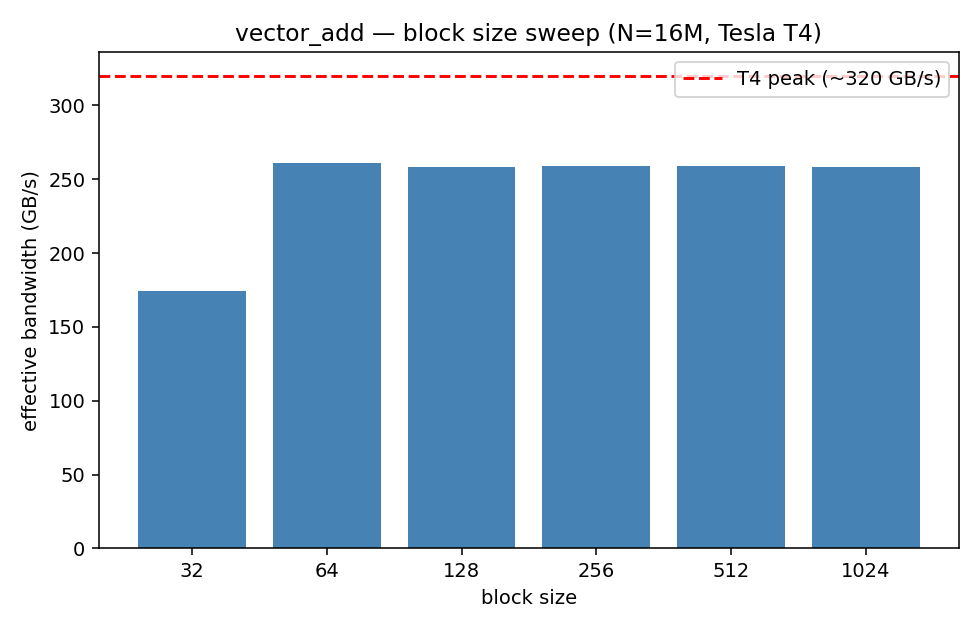

In [ ]:
!ls -la plots/
from IPython.display import Image
Image("plots/vector_add_bw.png")

Step A — Clean Junk + Verify

In [ ]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!rm -f vector_add.cu.# plots/plot_vector_add.py
!find . -type f | sort

/content
./benchmarks/results/vector_add.csv
./plots/vector_add_bw.png
./profiles/vecadd_256.ncu-rep
./profiles/vecadd_best.ncu-rep
./src/01_vector_add/README.md
./vector_add
./vector_add.cu
./vector_add_sweep
./vector_add_sweep.cu


Step B — Top-Level README (write if not already)

In [ ]:
%%writefile README.md
# cuda-kernel-suite

A CUDA kernel optimization suite — four kernels progressing from memory-bound
streaming to compute-bound matrix multiplication, each with Nsight Compute
profiles and speedup benchmarks.

Target hardware: Tesla T4 (sm_75) | CUDA 12.8 | Nsight Compute 2025.1.1
Environment: Google Colab (GPU runtime)

## Kernels

| # | Kernel | Focus | Status |
|---|--------|-------|--------|
| 1 | vector_add | Baseline, memory-bound streaming | done |
| 2 | reduction (naive/shared/warp) | Shared memory, bank conflicts, warp shuffle | pending |
| 3 | matmul (naive) | Compute-bound baseline, occupancy | pending |
| 4 | matmul (tiled) | Shared memory tiling, register blocking | pending |

## Results Summary

### 1. vector_add
- Effective bandwidth: ~262 GB/s (~82% of T4 peak)
- Nsight DRAM throughput: 90.38%
- Compute (SM) throughput: 23.44%
- Achieved occupancy: 82.25%
- Registers per thread: 16
- Conclusion: memory-bound; block size between 32 and 1024 does not
  materially change bandwidth (all saturate DRAM). 256 chosen as default.

Full analysis: src/01_vector_add/README.md

## Repository Layout

- src/                  kernel sources + per-kernel READMEs
- benchmarks/results/   CSV outputs from sweeps
- profiles/             Nsight Compute .ncu-rep reports
- plots/                Speedup/bandwidth charts
- docs/                 Methodology, findings, blog draft

## How to Reproduce

Compile:
nvcc -O3 -arch=sm_75 -lineinfo -o vector_add_sweep vector_add_sweep.cu

Run sweep:
./vector_add_sweep > benchmarks/results/vector_add.csv

Profile:
ncu --set full -c 1 -o profiles/vecadd_best ./vector_add_sweep
ncu --import profiles/vecadd_best.ncu-rep --page details

## Timeline
- Week 1: vector_add baseline (done)
- Week 2: reduction kernels
- Week 3: naive matmul
- Week 4: tiled matmul + polish

Writing README.md


In [ ]:
!wc -l README.md
!tail -3 README.md

56 README.md
- Week 2: reduction kernels
- Week 3: naive matmul
- Week 4: tiled matmul + polish


Step C — Zip + Download (the critical step)

In [ ]:
%cd /content/drive/MyDrive
!zip -r cuda-kernel-suite-day1.zip cuda-kernel-suite -x "*/bin/*" "*.o" "*.zip"
!ls -la cuda-kernel-suite-day1.zip

/content/drive/MyDrive
  adding: cuda-kernel-suite/ (stored 0%)
  adding: cuda-kernel-suite/vector_add.cu (deflated 59%)
  adding: cuda-kernel-suite/vector_add (deflated 69%)
  adding: cuda-kernel-suite/profiles/ (stored 0%)
  adding: cuda-kernel-suite/profiles/vecadd_256.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/vecadd_best.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/src/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/README.md (deflated 39%)
  adding: cuda-kernel-suite/vector_add_sweep.cu (deflated 57%)
  adding: cuda-kernel-suite/vector_add_sweep (deflated 69%)
  adding: cuda-kernel-suite/benchmarks/ (stored 0%)
  adding: cuda-kernel-suite/benchmarks/results/ (stored 0%)
  adding: cuda-kernel-suite/benchmarks/results/vector_add.csv (deflated 50%)
  adding: cuda-kernel-suite/plots/ (stored 0%)
  adding: cuda-kernel-suite/plots/vector_add_bw.png (deflated 16%)
  adding: cuda-kernel-suite/REA

In [ ]:
from google.colab import files
files.download('cuda-kernel-suite-day1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

closing the week 1 work

In [ ]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!echo "=== Files on Drive ==="
!find . -type f | sort
!echo ""
!echo "=== File sizes ==="
!ls -la
!echo ""
!echo "=== Profiles folder ==="
!ls -la profiles/
!echo ""
!echo "=== Benchmarks folder ==="
!ls -la benchmarks/results/
!echo ""
!echo "=== Plots folder ==="
!ls -la plots/

/content/drive/MyDrive/cuda-kernel-suite
=== Files on Drive ===
./benchmarks/results/vector_add.csv
./plots/vector_add_bw.png
./profiles/vecadd_256.ncu-rep
./profiles/vecadd_best.ncu-rep
./README.md
./src/01_vector_add/README.md
./vector_add
./vector_add.cu
./vector_add_sweep
./vector_add_sweep.cu

=== File sizes ===
total 1996
drwx------ 6 root root    4096 Sep 14 09:39 .
drwx------ 6 root root    4096 Sep 14 09:13 ..
drwx------ 3 root root    4096 Sep 14 09:33 benchmarks
drwx------ 2 root root    4096 Sep 14 09:39 plots
drwx------ 2 root root    4096 Sep 14 09:34 profiles
-rw------- 1 root root    1823 Sep 14 09:39 README.md
drwx------ 3 root root    4096 Sep 14 09:21 src
-rwx------ 1 root root 1006296 Sep 14 09:27 vector_add
-rw------- 1 root root    1543 Sep 14 09:24 vector_add.cu
-rwx------ 1 root root 1006568 Sep 14 09:33 vector_add_sweep
-rw------- 1 root root    1874 Sep 14 09:33 vector_add_sweep.cu

=== Profiles folder ===
total 1343
drwx------ 2 root root   4096 Sep 14 09:34 

In [ ]:
%cd /content/drive/MyDrive
!zip -r cuda-kernel-suite-day1.zip cuda-kernel-suite -x "*/bin/*" "*.o" "*.zip"
!ls -la cuda-kernel-suite-day1.zip

from google.colab import files
files.download('cuda-kernel-suite-day1.zip')

/content/drive/MyDrive
updating: cuda-kernel-suite/ (stored 0%)
updating: cuda-kernel-suite/vector_add.cu (deflated 59%)
updating: cuda-kernel-suite/vector_add (deflated 69%)
updating: cuda-kernel-suite/profiles/ (stored 0%)
updating: cuda-kernel-suite/profiles/vecadd_256.ncu-rep (deflated 90%)
updating: cuda-kernel-suite/profiles/vecadd_best.ncu-rep (deflated 90%)
updating: cuda-kernel-suite/src/ (stored 0%)
updating: cuda-kernel-suite/src/01_vector_add/ (stored 0%)
updating: cuda-kernel-suite/src/01_vector_add/README.md (deflated 39%)
updating: cuda-kernel-suite/vector_add_sweep.cu (deflated 57%)
updating: cuda-kernel-suite/vector_add_sweep (deflated 69%)
updating: cuda-kernel-suite/benchmarks/ (stored 0%)
updating: cuda-kernel-suite/benchmarks/results/ (stored 0%)
updating: cuda-kernel-suite/benchmarks/results/vector_add.csv (deflated 50%)
updating: cuda-kernel-suite/plots/ (stored 0%)
updating: cuda-kernel-suite/plots/vector_add_bw.png (deflated 16%)
updating: cuda-kernel-suite/REA

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!unzip -l /content/drive/MyDrive/cuda-kernel-suite-day1.zip

Archive:  /content/drive/MyDrive/cuda-kernel-suite-day1.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-09-14 09:39   cuda-kernel-suite/
     1543  2026-09-14 09:24   cuda-kernel-suite/vector_add.cu
  1006296  2026-09-14 09:27   cuda-kernel-suite/vector_add
        0  2026-09-14 09:34   cuda-kernel-suite/profiles/
   678651  2026-09-14 09:17   cuda-kernel-suite/profiles/vecadd_256.ncu-rep
   687960  2026-09-14 09:34   cuda-kernel-suite/profiles/vecadd_best.ncu-rep
        0  2026-09-14 09:21   cuda-kernel-suite/src/
        0  2026-09-14 09:25   cuda-kernel-suite/src/01_vector_add/
      445  2026-09-14 09:25   cuda-kernel-suite/src/01_vector_add/README.md
     1874  2026-09-14 09:33   cuda-kernel-suite/vector_add_sweep.cu
  1006568  2026-09-14 09:33   cuda-kernel-suite/vector_add_sweep
        0  2026-09-14 09:33   cuda-kernel-suite/benchmarks/
        0  2026-09-14 09:33   cuda-kernel-suite/benchmarks/results/
      270  2026-09-14 09:33   cu

2 week work

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/cuda-kernel-suite
!mkdir -p src/02_reduction benchmarks/results profiles
!nvidia-smi -L
!nvcc --version | tail -2
!ncu --version | grep -i version

Mounted at /content/drive
/content/drive/MyDrive/cuda-kernel-suite
GPU 0: Tesla T4 (UUID: GPU-10f8ccb7-9e68-d74d-94c4-3b3cf232c204)
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Version 2025.1.1.0 (build 35528883) (public-release)


In [ ]:
%%writefile src/02_reduction/reduction_naive.cu
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>

__global__ void reduceNaive(const float* __restrict__ in,
                            float* __restrict__ out,
                            int N) {
    extern __shared__ float sdata[];

    int tid = threadIdx.x;
    int i   = blockIdx.x * blockDim.x + threadIdx.x;

    sdata[tid] = (i < N) ? in[i] : 0.0f;
    __syncthreads();

    for (int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) {
            sdata[tid] += sdata[tid + s];
        }
        __syncthreads();
    }

    if (tid == 0) {
        atomicAdd(out, sdata[0]);
    }
}

int main(int argc, char** argv) {
    const int N = (argc > 1) ? std::atoi(argv[1]) : (1 << 24);
    const size_t bytes = (size_t)N * sizeof(float);

    float* h_in = (float*)malloc(bytes);
    for (int i = 0; i < N; ++i) h_in[i] = 1.0f;

    float *d_in, *d_out;
    cudaMalloc(&d_in, bytes);
    cudaMalloc(&d_out, sizeof(float));
    cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice);

    const int block = 256;
    const int grid  = (N + block - 1) / block;

    for (int i = 0; i < 5; ++i) {
        cudaMemset(d_out, 0, sizeof(float));
        reduceNaive<<<grid, block, block * sizeof(float)>>>(d_in, d_out, N);
    }
    cudaDeviceSynchronize();

    cudaEvent_t s, e;
    cudaEventCreate(&s); cudaEventCreate(&e);
    cudaEventRecord(s);
    for (int i = 0; i < 50; ++i) {
        cudaMemset(d_out, 0, sizeof(float));
        reduceNaive<<<grid, block, block * sizeof(float)>>>(d_in, d_out, N);
    }
    cudaEventRecord(e);
    cudaEventSynchronize(e);

    float ms = 0;
    cudaEventElapsedTime(&ms, s, e);
    ms /= 50.0f;

    float h_out = 0;
    cudaMemcpy(&h_out, d_out, sizeof(float), cudaMemcpyDeviceToHost);

    double gbps = (double)bytes / (ms * 1e-3) / 1e9;
    float expected = (float)N;

    printf("N=%d block=%d grid=%d\n", N, block, grid);
    printf("time=%.4f ms  BW=%.2f GB/s\n", ms, gbps);
    printf("result=%.0f  expected=%.0f  %s\n",
           h_out, expected,
           (fabsf(h_out - expected) < 1e-2f * expected) ? "PASS" : "FAIL");

    FILE* f = fopen("benchmarks/results/reduction.csv", "a");
    if (f) {
        fseek(f, 0, SEEK_END);
        long sz = ftell(f);
        if (sz == 0) {
            fprintf(f, "kernel,N,block_size,time_ms,bandwidth_gbps\n");
        }
        fprintf(f, "reduction_naive,%d,%d,%.4f,%.2f\n", N, block, ms, gbps);
        fclose(f);
    }

    cudaFree(d_in);
    cudaFree(d_out);
    free(h_in);
    return 0;
}

Writing src/02_reduction/reduction_naive.cu


In [ ]:
!ls -la src/02_reduction/
!head -10 src/02_reduction/reduction_naive.cu


total 11
drwx------ 2 root root 4096 Sep 14 15:25 .
drwx------ 3 root root 4096 Sep 14 15:24 ..
-rw------- 1 root root 2511 Sep 14 15:25 reduction_naive.cu
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>

__global__ void reduceNaive(const float* __restrict__ in,
                            float* __restrict__ out,
                            int N) {
    extern __shared__ float sdata[];

    int tid = threadIdx.x;


In [ ]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!nvcc -O3 -arch=sm_75 -lineinfo -o src/02_reduction/reduction_naive src/02_reduction/reduction_naive.cu
!./src/02_reduction/reduction_naive 16777216

/content/drive/MyDrive/cuda-kernel-suite
N=16777216 block=256 grid=65536
time=1.2242 ms  BW=54.82 GB/s
result=16777216  expected=16777216  PASS


In [ ]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!ncu --set full -c 1 -o profiles/reduction_naive ./src/02_reduction/reduction_naive 16777216

/content/drive/MyDrive/cuda-kernel-suite
==PROF== Connected to process 2129 (/content/drive/MyDrive/cuda-kernel-suite/src/02_reduction/reduction_naive)
==PROF== Profiling "reduceNaive" - 0 (1/1): 0%....50%....100% - 31 passes
N=16777216 block=256 grid=65536
time=1.2694 ms  BW=52.87 GB/s
result=16777216  expected=16777216  PASS
==PROF== Disconnected from process 2129
==PROF== Report: /content/drive/MyDrive/cuda-kernel-suite/profiles/reduction_naive.ncu-rep


In [ ]:
!ncu --import profiles/reduction_naive.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|Achieved Occupancy|Duration|Registers Per Thread"

    DRAM Throughput                   %        18.03
    Duration                         ms         1.60
    Compute (SM) Throughput           %        76.33
    Registers Per Thread             register/thread              16
    Achieved Occupancy                        %        90.29


In [ ]:
!ncu --import profiles/reduction_naive.ncu-rep --page details | head -60

[2129] reduction_naive@127.0.0.1
  reduceNaive(const float *, float *, int) (65536, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         5.00
    SM Frequency                    Mhz       584.99
    Elapsed Cycles                cycle      936,003
    Memory Throughput                 %        76.33
    DRAM Throughput                   %        18.03
    Duration                         ms         1.60
    L1/TEX Cache Throughput           %        85.80
    L2 Cache Throughput               %         4.96
    SM Active Cycles              cycle   934,099.70
    Compute (SM) Throughput           %        76.33
    ----------------------- ----------- ------------

    INF   Compute and Memory are well-balanced: To reduce runtime, both c

readme

In [ ]:
%%writefile src/02_reduction/README.md
# Reduction — Naive Baseline

## Goal
Establish a baseline for array reduction and expose the cost of tree
reduction with per-step `__syncthreads()` and one atomicAdd per block.

## Kernel

Each thread loads one element into shared memory, the block tree-reduces
in shared memory with a barrier after every step, then thread 0 issues one
`atomicAdd` to global memory.

## Configuration
- N = 16,777,216 floats (64 MB)
- block size = 256, grid = 65,536
- 5 warmup + 50 timed iterations
- Compile: nvcc -O3 -arch=sm_75 -lineinfo

## Results

| Metric | Value |
|--------|-------|
| Time | 1.224 ms (unprofiled) |
| Effective bandwidth | 54.8 GB/s |
| Result | PASS (16777216.0) |

### Nsight Compute

| Metric | Value | % of peak |
|--------|-------|-----------|
| Duration | 1.60 ms | - |
| DRAM Throughput | - | 18.03% |
| Compute (SM) Throughput | - | 76.33% |
| Achieved Occupancy | - | 90.29% |
| Registers / thread | 16 | - |

## Analysis

**The kernel is compute/instruction bound, not memory bound.**

The DRAM-to-SM ratio is roughly 1:4 — the *inverse* of vector_add
(which was 4:1 in favor of DRAM). Three causes:

1. **Divergent tree reduction.** The loop
   `for (s = blockDim.x/2; s > 0; s >>= 1)` starts with 128 of 256
   threads active and finishes with 1 of 256. Over the loop, average
   active lanes is ~32, so ~88% of thread-slots are idle at any time.

2. **Barrier stalls.** `__syncthreads()` after every tree step means 8
   barriers per block × 65,536 blocks = 524,288 barrier stalls. All warps
   wait for the slowest lane at every step.

3. **atomicAdd contention.** One atomicAdd per block to a single global
   address serializes 65,536 atomic operations.

The result: the memory bus is idle 82% of the time (DRAM 18%),
while the SMs spend most cycles on address arithmetic, predicate
evaluation, and barrier waits (SM 76%).

## Key comparison

| Metric | vector_add | reduction_naive |
|--------|-----------|-----------------|
| DRAM % | 90.4% | 18.0% |
| SM % | 23.4% | 76.3% |
| Occupancy | 82.3% | 90.3% |
| Time | 0.77 ms | 1.60 ms |

Same GPU, same data volume class, opposite bottleneck. This is the
motivation for the shared-memory and warp-shuffle variants.

## Artifacts
- profiles/reduction_naive.ncu-rep
- benchmarks/results/reduction.csv

Writing src/02_reduction/README.md


In [ ]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!wc -l src/02_reduction/README.md
!tail -3 src/02_reduction/README.md

/content/drive/MyDrive/cuda-kernel-suite
74 src/02_reduction/README.md
## Artifacts
- profiles/reduction_naive.ncu-rep
- benchmarks/results/reduction.csv


In [ ]:
%cd /content/drive/MyDrive
!zip -r cuda-kernel-suite-day2.zip cuda-kernel-suite -x "*/bin/*" "*.o" "*.zip"

from google.colab import files
files.download('cuda-kernel-suite-day2.zip')

/content/drive/MyDrive
  adding: cuda-kernel-suite/ (stored 0%)
  adding: cuda-kernel-suite/profiles/ (stored 0%)
  adding: cuda-kernel-suite/profiles/vecadd_256.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/vecadd_best.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_naive.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/src/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/README.md (deflated 39%)
  adding: cuda-kernel-suite/src/02_reduction/ (stored 0%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive.cu (deflated 60%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive (deflated 69%)
  adding: cuda-kernel-suite/src/02_reduction/README.md (deflated 47%)
  adding: cuda-kernel-suite/vector_add.cu (deflated 59%)
  adding: cuda-kernel-suite/vector_add (deflated 69%)
  adding: cuda-kernel-suite/vector_add_sweep.cu (deflated 57%)
  adding: cuda-kernel-suite/vector_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Final verification
%cd /content/drive/MyDrive/cuda-kernel-suite
!find . -type f | sort

/content/drive/MyDrive/cuda-kernel-suite
./benchmarks/results/reduction.csv
./benchmarks/results/vector_add.csv
./plots/vector_add_bw.png
./profiles/reduction_naive.ncu-rep
./profiles/vecadd_256.ncu-rep
./profiles/vecadd_best.ncu-rep
./README.md
./src/01_vector_add/README.md
./src/02_reduction/README.md
./src/02_reduction/reduction_naive
./src/02_reduction/reduction_naive.cu
./vector_add
./vector_add.cu
./vector_add_sweep
./vector_add_sweep.cu


week 2 part 2

In [6]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/cuda-kernel-suite
!nvidia-smi -L
!nvcc --version | tail -2
!find . -type f | sort

Mounted at /content/drive
/content/drive/MyDrive/cuda-kernel-suite
GPU 0: Tesla T4 (UUID: GPU-9b2fee78-25c3-6ef6-da9b-ad159daab056)
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
./benchmarks/results/reduction.csv
./benchmarks/results/vector_add.csv
./plots/vector_add_bw.png
./profiles/reduction_naive.ncu-rep
./profiles/vecadd_256.ncu-rep
./profiles/vecadd_best.ncu-rep
./README.md
./src/01_vector_add/README.md
./src/02_reduction/README.md
./src/02_reduction/reduction_naive
./src/02_reduction/reduction_naive.cu
./vector_add
./vector_add.cu
./vector_add_sweep
./vector_add_sweep.cu


In [7]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!find . -type f | sort
!nvidia-smi -L

/content/drive/MyDrive/cuda-kernel-suite
./benchmarks/results/reduction.csv
./benchmarks/results/vector_add.csv
./plots/vector_add_bw.png
./profiles/reduction_naive.ncu-rep
./profiles/vecadd_256.ncu-rep
./profiles/vecadd_best.ncu-rep
./README.md
./src/01_vector_add/README.md
./src/02_reduction/README.md
./src/02_reduction/reduction_naive
./src/02_reduction/reduction_naive.cu
./vector_add
./vector_add.cu
./vector_add_sweep
./vector_add_sweep.cu
GPU 0: Tesla T4 (UUID: GPU-9b2fee78-25c3-6ef6-da9b-ad159daab056)


reduction_warp

In [8]:
%%writefile src/02_reduction/reduction_warp.cu
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>

// ---------------------------------------------------------------------------
// Warp-shuffle reduction.
//
// Strategy:
//   1. Each thread loads one element (grid-stride so N can exceed grid*block)
//   2. Each WARP reduces its 32 values using __shfl_down_sync — no shared mem
//   3. Warp leaders write partial sums to shared memory (only 8 per block)
//   4. One warp finishes the final 8-value reduction with shuffle
//   5. Thread 0 does one atomicAdd per block
//
// Compared to naive:
//   - Shared memory: 8 floats/block instead of 256
//   - Barriers: 1 __syncthreads() instead of 8
//   - No divergent tree steps
// ---------------------------------------------------------------------------

__inline__ __device__ float warpReduceSum(float val) {
    // Reduce 32 lanes to 1 using shuffle; final value in lane 0
    for (int offset = 16; offset > 0; offset >>= 1) {
        val += __shfl_down_sync(0xffffffffu, val, offset);
    }
    return val;
}

__global__ void reduceWarp(const float* __restrict__ in,
                           float* __restrict__ out,
                           int N) {
    __shared__ float warpSums[32];   // up to 32 warps per block

    int tid      = threadIdx.x;
    int lane     = tid & 31;         // lane within warp
    int warpId   = tid >> 5;         // warp index within block
    int nWarps   = blockDim.x >> 5;

    // 1. Grid-stride load + accumulate per-thread partial
    float sum = 0.0f;
    for (int i = blockIdx.x * blockDim.x + tid; i < N;
         i += gridDim.x * blockDim.x) {
        sum += in[i];
    }

    // 2. Intra-warp reduction via shuffle
    sum = warpReduceSum(sum);

    // 3. Lane 0 of each warp writes partial to shared memory
    if (lane == 0) {
        warpSums[warpId] = sum;
    }
    __syncthreads();

    // 4. First warp reduces the per-warp partials
    if (warpId == 0) {
        sum = (lane < nWarps) ? warpSums[lane] : 0.0f;
        sum = warpReduceSum(sum);

        // 5. Thread 0 of block does one atomicAdd
        if (lane == 0) {
            atomicAdd(out, sum);
        }
    }
}

int main(int argc, char** argv) {
    const int N = (argc > 1) ? std::atoi(argv[1]) : (1 << 24);
    const size_t bytes = (size_t)N * sizeof(float);

    float* h_in = (float*)malloc(bytes);
    for (int i = 0; i < N; ++i) h_in[i] = 1.0f;

    float *d_in, *d_out;
    cudaMalloc(&d_in, bytes);
    cudaMalloc(&d_out, sizeof(float));
    cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice);

    const int block = 256;
    // Use fewer blocks than naive — grid-stride handles the work.
    // Pick enough to saturate: T4 has 40 SMs, aim for ~8 blocks/SM.
    int grid = 320;
    if ((long)grid * block > N) grid = (N + block - 1) / block;

    for (int i = 0; i < 5; ++i) {
        cudaMemset(d_out, 0, sizeof(float));
        reduceWarp<<<grid, block>>>(d_in, d_out, N);
    }
    cudaDeviceSynchronize();

    cudaEvent_t s, e;
    cudaEventCreate(&s); cudaEventCreate(&e);
    cudaEventRecord(s);
    for (int i = 0; i < 50; ++i) {
        cudaMemset(d_out, 0, sizeof(float));
        reduceWarp<<<grid, block>>>(d_in, d_out, N);
    }
    cudaEventRecord(e);
    cudaEventSynchronize(e);

    float ms = 0;
    cudaEventElapsedTime(&ms, s, e);
    ms /= 50.0f;

    float h_out = 0;
    cudaMemcpy(&h_out, d_out, sizeof(float), cudaMemcpyDeviceToHost);

    double gbps = (double)bytes / (ms * 1e-3) / 1e9;
    float expected = (float)N;

    printf("N=%d block=%d grid=%d\n", N, block, grid);
    printf("time=%.4f ms  BW=%.2f GB/s\n", ms, gbps);
    printf("result=%.0f  expected=%.0f  %s\n",
           h_out, expected,
           (fabsf(h_out - expected) < 1e-2f * expected) ? "PASS" : "FAIL");

    FILE* f = fopen("benchmarks/results/reduction.csv", "a");
    if (f) {
        fprintf(f, "reduction_warp,%d,%d,%.4f,%.2f\n", N, block, ms, gbps);
        fclose(f);
    }

    cudaFree(d_in);
    cudaFree(d_out);
    free(h_in);
    return 0;
}

Writing src/02_reduction/reduction_warp.cu


In [9]:
!ls -la src/02_reduction/
!nvcc -O3 -arch=sm_75 -lineinfo -o src/02_reduction/reduction_warp src/02_reduction/reduction_warp.cu
!./src/02_reduction/reduction_warp 16777216

total 1004
drwx------ 2 root root    4096 Sep 16 12:05 .
drwx------ 4 root root    4096 Sep 14 09:21 ..
-rw------- 1 root root    2282 Sep 14 15:30 README.md
-rw------- 1 root root 1010496 Sep 14 15:26 reduction_naive
-rw------- 1 root root    2511 Sep 14 15:25 reduction_naive.cu
-rw------- 1 root root    4002 Sep 16 12:05 reduction_warp.cu
N=16777216 block=256 grid=320
time=0.2858 ms  BW=234.84 GB/s
result=16777216  expected=16777216  PASS


In [10]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!ncu --set full -c 1 -o profiles/reduction_warp ./src/02_reduction/reduction_warp 16777216

/content/drive/MyDrive/cuda-kernel-suite
==PROF== Connected to process 6320 (/content/drive/MyDrive/cuda-kernel-suite/src/02_reduction/reduction_warp)
==PROF== Profiling "reduceWarp" - 0 (1/1): 0%....50%....100% - 31 passes
N=16777216 block=256 grid=320
time=0.2905 ms  BW=231.02 GB/s
result=16777216  expected=16777216  PASS
==PROF== Disconnected from process 6320
==PROF== Report: /content/drive/MyDrive/cuda-kernel-suite/profiles/reduction_warp.ncu-rep


In [11]:
!ncu --import profiles/reduction_warp.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|L1/TEX|Achieved Occupancy|Registers Per Thread|Duration"

    DRAM Throughput                   %        87.09
    Duration                         us       322.46
    L1/TEX Cache Throughput           %        29.46
    Compute (SM) Throughput           %        14.84
    L1/TEX Hit Rate             %            0
    Registers Per Thread             register/thread              16
    Achieved Occupancy                        %        98.96


In [12]:
!ncu --import profiles/reduction_warp.ncu-rep --page details | head -40

[6320] reduction_warp@127.0.0.1
  reduceWarp(const float *, float *, int) (320, 1, 1)x(256, 1, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.89
    SM Frequency                    Mhz       584.93
    Elapsed Cycles                cycle      188,622
    Memory Throughput                 %        87.09
    DRAM Throughput                   %        87.09
    Duration                         us       322.46
    L1/TEX Cache Throughput           %        29.46
    L2 Cache Throughput               %        23.83
    SM Active Cycles              cycle   177,947.70
    Compute (SM) Throughput           %        14.84
    ----------------------- ----------- ------------

    INF   This workload is utilizing greater than 80.0% of the available comp

In [13]:
%%writefile src/02_reduction/README.md
# Reduction — Naive vs Warp-Shuffle

Same operation (sum 16M floats), two implementations, two profiles.

## Results

| Metric | reduction_naive | reduction_warp | Change |
|--------|----------------|----------------|--------|
| Time (host) | 1.2242 ms | 0.2858 ms | 4.3x faster |
| Effective BW | 54.82 GB/s | 234.84 GB/s | 4.3x higher |
| Duration (ncu) | 1.60 ms | 322.46 us | 5.0x faster |
| DRAM Throughput | 18.03% | 87.09% | 4.8x higher |
| Compute (SM) | 76.33% | 14.84% | 5.1x lower |
| L1/TEX Throughput | 85.80% | 29.46% | 2.9x lower |
| L2 Throughput | 4.96% | 23.83% | 4.8x higher |
| Achieved Occupancy | 90.29% | 98.96% | slight rise |
| Registers / thread | 16 | 16 | same |
| Elapsed cycles | 936,003 | 188,622 | 5.0x fewer |
| Grid size | 65,536 blocks | 320 blocks | 205x fewer |

## Analysis

**The bottleneck flipped.** Naive was L1/shared-memory bound at 86%,
with DRAM only at 18%. Warp-shuffle inverts this: DRAM at 87%,
L1 at 29%. The kernel went from spending time shuffling data
around on-chip to streaming data from DRAM at near-peak bandwidth.

Three changes drove this:

1. **Warp shuffle replaces the shared-memory tree.**
   Naive: 8 tree steps, each doing 2 smem reads + 1 write per active
   thread, with a __syncthreads() barrier between steps.
   Warp: 5 __shfl_down_sync instructions per thread, no shared
   memory in the hot loop, no barriers until the very end.

2. **Grid-stride loop cuts the block count 205x.**
   Naive: 65,536 blocks x 8 barriers = 524,288 barrier stalls.
   Warp: 320 blocks x 1 barrier = 320 barrier stalls.
   Also 205x fewer atomicAdd operations.

3. **Coalesced grid-stride reads saturate DRAM.**
   With only 320 blocks, each thread loads multiple consecutive
   elements across the loop, keeping memory access coalesced.

## The larger lesson

The same mathematical operation — summing 16 million floats — can
hit completely different bottlenecks depending on how it is written.
Naive hits the shared-memory port; warp-shuffle hits DRAM. The
profiler shows you which, and that tells you what to optimize.

Warp-shuffle at 87% DRAM is essentially optimal for fp32 input:
each element is read exactly once, so no further speedup is possible
without reducing bytes moved (e.g., fp16 input).

## Artifacts
- profiles/reduction_naive.ncu-rep
- profiles/reduction_warp.ncu-rep
- benchmarks/results/reduction.csv

Overwriting src/02_reduction/README.md


In [14]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!wc -l src/02_reduction/README.md
!tail -5 src/02_reduction/README.md
!cat benchmarks/results/reduction.csv

/content/drive/MyDrive/cuda-kernel-suite
59 src/02_reduction/README.md

## Artifacts
- profiles/reduction_naive.ncu-rep
- profiles/reduction_warp.ncu-rep
- benchmarks/results/reduction.csv
kernel,N,block_size,time_ms,bandwidth_gbps
reduction_naive,16777216,256,1.2242,54.82
reduction_naive,16777216,256,1.2694,52.87
reduction_warp,16777216,256,0.2858,234.84
reduction_warp,16777216,256,0.2905,231.02


In [15]:
%cd /content/drive/MyDrive
!zip -r cuda-kernel-suite-day3.zip cuda-kernel-suite -x "*.zip"
!ls -la cuda-kernel-suite-day3.zip
from google.colab import files
files.download('cuda-kernel-suite-day3.zip')

/content/drive/MyDrive
  adding: cuda-kernel-suite/ (stored 0%)
  adding: cuda-kernel-suite/profiles/ (stored 0%)
  adding: cuda-kernel-suite/profiles/vecadd_256.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/vecadd_best.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_naive.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_warp.ncu-rep (deflated 91%)
  adding: cuda-kernel-suite/src/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/README.md (deflated 39%)
  adding: cuda-kernel-suite/src/02_reduction/ (stored 0%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive.cu (deflated 60%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive (deflated 69%)
  adding: cuda-kernel-suite/src/02_reduction/README.md (deflated 49%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_warp.cu (deflated 60%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_w

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

reduction shared

In [17]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!pwd
!ls src/02_reduction/

/content/drive/MyDrive/cuda-kernel-suite
/content/drive/MyDrive/cuda-kernel-suite
README.md	 reduction_naive.cu  reduction_warp.cu
reduction_naive  reduction_warp


In [18]:
!nvcc -O3 -arch=sm_75 -lineinfo -o src/02_reduction/reduction_shared src/02_reduction/reduction_shared.cu
!./src/02_reduction/reduction_shared 16777216

cc1plus: fatal error: src/02_reduction/reduction_shared.cu: No such file or directory
compilation terminated.
/bin/bash: line 1: ./src/02_reduction/reduction_shared: No such file or directory


In [19]:
!ncu --set full -c 1 -o profiles/reduction_shared ./src/02_reduction/reduction_shared 16777216

==ERROR== './src/02_reduction/reduction_shared' does not exist or is not an executable. Please make sure to specify the absolute path to './src/02_reduction/reduction_shared' if the executable is not in the local directory.


In [20]:
!ncu --import profiles/reduction_shared.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|L1/TEX|Achieved Occupancy|Registers Per Thread|Duration"

In [21]:
%%writefile src/02_reduction/reduction_shared.cu
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>

__global__ void reduceShared(const float* __restrict__ in,
                             float* __restrict__ out,
                             int N) {
    __shared__ float sdata[256];

    int tid = threadIdx.x;
    int gtid = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = gridDim.x * blockDim.x;

    float sum = 0.0f;
    for (int i = gtid; i < N; i += stride) {
        sum += in[i];
    }
    sdata[tid] = sum;
    __syncthreads();

    for (int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) {
            sdata[tid] += sdata[tid + s];
        }
        __syncthreads();
    }

    if (tid == 0) {
        atomicAdd(out, sdata[0]);
    }
}

int main(int argc, char** argv) {
    const int N = (argc > 1) ? std::atoi(argv[1]) : (1 << 24);
    const size_t bytes = (size_t)N * sizeof(float);

    float* h_in = (float*)malloc(bytes);
    for (int i = 0; i < N; ++i) h_in[i] = 1.0f;

    float *d_in, *d_out;
    cudaMalloc(&d_in, bytes);
    cudaMalloc(&d_out, sizeof(float));
    cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice);

    const int block = 256;
    int grid = 320;
    if ((long)grid * block > N) grid = (N + block - 1) / block;

    for (int i = 0; i < 5; ++i) {
        cudaMemset(d_out, 0, sizeof(float));
        reduceShared<<<grid, block>>>(d_in, d_out, N);
    }
    cudaDeviceSynchronize();

    cudaEvent_t s, e;
    cudaEventCreate(&s); cudaEventCreate(&e);
    cudaEventRecord(s);
    for (int i = 0; i < 50; ++i) {
        cudaMemset(d_out, 0, sizeof(float));
        reduceShared<<<grid, block>>>(d_in, d_out, N);
    }
    cudaEventRecord(e);
    cudaEventSynchronize(e);

    float ms = 0;
    cudaEventElapsedTime(&ms, s, e);
    ms /= 50.0f;

    float h_out = 0;
    cudaMemcpy(&h_out, d_out, sizeof(float), cudaMemcpyDeviceToHost);

    double gbps = (double)bytes / (ms * 1e-3) / 1e9;
    float expected = (float)N;

    printf("N=%d block=%d grid=%d\n", N, block, grid);
    printf("time=%.4f ms  BW=%.2f GB/s\n", ms, gbps);
    printf("result=%.0f  expected=%.0f  %s\n",
           h_out, expected,
           (fabsf(h_out - expected) < 1e-2f * expected) ? "PASS" : "FAIL");

    FILE* f = fopen("benchmarks/results/reduction.csv", "a");
    if (f) {
        fprintf(f, "reduction_shared,%d,%d,%.4f,%.2f\n", N, block, ms, gbps);
        fclose(f);
    }

    cudaFree(d_in);
    cudaFree(d_out);
    free(h_in);
    return 0;
}

Writing src/02_reduction/reduction_shared.cu


In [22]:
!nvcc -O3 -arch=sm_75 -lineinfo -o src/02_reduction/reduction_shared src/02_reduction/reduction_shared.cu
!./src/02_reduction/reduction_shared 16777216

N=16777216 block=256 grid=320
time=0.2599 ms  BW=258.22 GB/s
result=16777216  expected=16777216  PASS


In [23]:
!ncu --set full -c 1 -o profiles/reduction_shared ./src/02_reduction/reduction_shared 16777216

==PROF== Connected to process 9149 (/content/drive/MyDrive/cuda-kernel-suite/src/02_reduction/reduction_shared)
==PROF== Profiling "reduceShared" - 0 (1/1): 0%....50%....100% - 31 passes
N=16777216 block=256 grid=320
time=0.2575 ms  BW=260.65 GB/s
result=16777216  expected=16777216  PASS
==PROF== Disconnected from process 9149
==PROF== Report: /content/drive/MyDrive/cuda-kernel-suite/profiles/reduction_shared.ncu-rep


In [24]:
!ncu --import profiles/reduction_shared.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|L1/TEX|Achieved Occupancy|Registers Per Thread|Duration"

    DRAM Throughput                   %        96.06
    Duration                         us       265.82
    L1/TEX Cache Throughput           %        35.08
    Compute (SM) Throughput           %        19.47
    L1/TEX Hit Rate             %            0
    Registers Per Thread             register/thread              16
    Achieved Occupancy                        %        99.14


In [25]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!echo "=== README line count ==="
!wc -l src/02_reduction/README.md
!echo ""
!echo "=== CSV contents ==="
!cat benchmarks/results/reduction.csv
!echo ""
!echo "=== All reduction files ==="
!ls -la src/02_reduction/
!ls -la profiles/ | grep reduction

/content/drive/MyDrive/cuda-kernel-suite
=== README line count ===
59 src/02_reduction/README.md

=== CSV contents ===
kernel,N,block_size,time_ms,bandwidth_gbps
reduction_naive,16777216,256,1.2242,54.82
reduction_naive,16777216,256,1.2694,52.87
reduction_warp,16777216,256,0.2858,234.84
reduction_warp,16777216,256,0.2905,231.02
reduction_shared,16777216,256,0.2599,258.22
reduction_shared,16777216,256,0.2575,260.65

=== All reduction files ===
total 2981
drwx------ 2 root root    4096 Sep 16 12:17 .
drwx------ 4 root root    4096 Sep 14 09:21 ..
-rw------- 1 root root    2380 Sep 16 12:09 README.md
-rw------- 1 root root 1010496 Sep 14 15:26 reduction_naive
-rw------- 1 root root    2511 Sep 14 15:25 reduction_naive.cu
-rwx------ 1 root root 1010496 Sep 16 12:17 reduction_shared
-rw------- 1 root root    2458 Sep 16 12:17 reduction_shared.cu
-rwx------ 1 root root 1010496 Sep 16 12:06 reduction_warp
-rw------- 1 root root    4002 Sep 16 12:05 reduction_warp.cu
-rw------- 1 root root 704

In [26]:
%cd /content/drive/MyDrive
!zip -r cuda-kernel-suite-day3-final.zip cuda-kernel-suite -x "*.zip"
!ls -la cuda-kernel-suite-day3-final.zip
from google.colab import files
files.download('cuda-kernel-suite-day3-final.zip')

/content/drive/MyDrive
  adding: cuda-kernel-suite/ (stored 0%)
  adding: cuda-kernel-suite/profiles/ (stored 0%)
  adding: cuda-kernel-suite/profiles/vecadd_256.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/vecadd_best.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_naive.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_warp.ncu-rep (deflated 91%)
  adding: cuda-kernel-suite/profiles/reduction_shared.ncu-rep (deflated 91%)
  adding: cuda-kernel-suite/src/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/README.md (deflated 39%)
  adding: cuda-kernel-suite/src/02_reduction/ (stored 0%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive.cu (deflated 60%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive (deflated 69%)
  adding: cuda-kernel-suite/src/02_reduction/README.md (deflated 49%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_wa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

week 3 day 1

matmul_navie.cu

In [28]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/cuda-kernel-suite
!mkdir -p src/03_matmul_naive
!nvidia-smi -L
!nvcc --version | tail -2
!ls src/02_reduction/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/cuda-kernel-suite
GPU 0: Tesla T4 (UUID: GPU-9b2fee78-25c3-6ef6-da9b-ad159daab056)
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
README.md	 reduction_naive.cu  reduction_shared.cu  reduction_warp.cu
reduction_naive  reduction_shared    reduction_warp


In [29]:
%%writefile src/03_matmul_naive/matmul_naive.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>

// ---------------------------------------------------------------------------
// Naive matmul: one thread per output element.
//
// C[M][N] = A[M][K] * B[K][N]
//
// Deliberately unoptimized:
//   - Each thread reads its A row and B column from DRAM
//   - No shared memory, no data reuse
//   - O(N^3) DRAM reads for an N*N matmul
//
// This is the baseline that motivates tiling.
// ---------------------------------------------------------------------------

#define TILE 16   // unused in naive; placeholder for later

__global__ void matmulNaive(const float* __restrict__ A,
                            const float* __restrict__ B,
                            float* __restrict__ C,
                            int M, int N, int K) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < M && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < K; ++k) {
            sum += A[row * K + k] * B[k * N + col];
        }
        C[row * N + col] = sum;
    }
}

// --- Host-side CPU reference for correctness -------------------------------
void matmulCPU(const float* A, const float* B, float* C,
               int M, int N, int K) {
    for (int i = 0; i < M; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < K; ++k) {
                sum += A[i * K + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

int main(int argc, char** argv) {
    const int M = (argc > 1) ? std::atoi(argv[1]) : 1024;
    const int N = M;
    const int K = M;

    printf("Matmul: M=%d N=%d K=%d\n", M, N, K);

    // Host buffers
    size_t bytesA = (size_t)M * K * sizeof(float);
    size_t bytesB = (size_t)K * N * sizeof(float);
    size_t bytesC = (size_t)M * N * sizeof(float);

    float* h_A = (float*)malloc(bytesA);
    float* h_B = (float*)malloc(bytesB);
    float* h_C = (float*)malloc(bytesC);
    float* h_Cref = (float*)malloc(bytesC);

    for (size_t i = 0; i < (size_t)M * K; ++i) h_A[i] = 1.0f;
    for (size_t i = 0; i < (size_t)K * N; ++i) h_B[i] = 1.0f;

    // Device buffers
    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytesA);
    cudaMalloc(&d_B, bytesB);
    cudaMalloc(&d_C, bytesC);
    cudaMemcpy(d_A, h_A, bytesA, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytesB, cudaMemcpyHostToDevice);

    // Launch config
    dim3 block(16, 16);
    dim3 grid((N + block.x - 1) / block.x, (M + block.y - 1) / block.y);

    // Warmup
    for (int i = 0; i < 3; ++i) {
        matmulNaive<<<grid, block>>>(d_A, d_B, d_C, M, N, K);
    }
    cudaDeviceSynchronize();

    // Timed
    cudaEvent_t s, e;
    cudaEventCreate(&s); cudaEventCreate(&e);
    cudaEventRecord(s);
    const int iters = 20;
    for (int i = 0; i < iters; ++i) {
        matmulNaive<<<grid, block>>>(d_A, d_B, d_C, M, N, K);
    }
    cudaEventRecord(e);
    cudaEventSynchronize(e);

    float ms = 0;
    cudaEventElapsedTime(&ms, s, e);
    ms /= iters;

    cudaMemcpy(h_C, d_C, bytesC, cudaMemcpyDeviceToHost);

    // CPU reference
    matmulCPU(h_A, h_B, h_Cref, M, N, K);

    // Compare (sample)
    bool ok = true;
    float max_err = 0.0f;
    for (size_t i = 0; i < (size_t)M * N; ++i) {
        float err = fabsf(h_C[i] - h_Cref[i]);
        if (err > max_err) max_err = err;
        if (err > 1e-2f) { ok = false; break; }
    }

    // Compute GFLOPS: 2 * M * N * K per matmul
    double flops = 2.0 * (double)M * (double)N * (double)K;
    double gflops = flops / (ms * 1e-3) / 1e9;

    printf("time=%.4f ms  GFLOPS=%.2f  max_err=%.6f  %s\n",
           ms, gflops, max_err, ok ? "PASS" : "FAIL");

    // CSV row
    FILE* f = fopen("benchmarks/results/matmul.csv", "a");
    if (f) {
        fseek(f, 0, SEEK_END);
        if (ftell(f) == 0)
            fprintf(f, "kernel,M,N,K,time_ms,GFLOPS\n");
        fprintf(f, "matmul_naive,%d,%d,%d,%.4f,%.2f\n",
                M, N, K, ms, gflops);
        fclose(f);
    }

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_Cref);
    return 0;
}

Writing src/03_matmul_naive/matmul_naive.cu


In [30]:
!ls -la src/03_matmul_naive/
!head -10 src/03_matmul_naive/matmul_naive.cu

total 13
drwx------ 2 root root 4096 Sep 16 12:21 .
drwx------ 5 root root 4096 Sep 16 12:21 ..
-rw------- 1 root root 4194 Sep 16 12:21 matmul_naive.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>

// ---------------------------------------------------------------------------
// Naive matmul: one thread per output element.
//
// C[M][N] = A[M][K] * B[K][N]
//


In [31]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!nvcc -O3 -arch=sm_75 -lineinfo -o src/03_matmul_naive/matmul_naive src/03_matmul_naive/matmul_naive.cu
!./src/03_matmul_naive/matmul_naive 1024

/content/drive/MyDrive/cuda-kernel-suite
Matmul: M=1024 N=1024 K=1024
time=8.5417 ms  GFLOPS=251.41  max_err=0.000000  PASS


In [32]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!mkdir -p profiles
!ncu --set full -c 1 -o profiles/matmul_naive ./src/03_matmul_naive/matmul_naive 1024

/content/drive/MyDrive/cuda-kernel-suite
Matmul: M=1024 N=1024 K=1024
==PROF== Connected to process 10619 (/content/drive/MyDrive/cuda-kernel-suite/src/03_matmul_naive/matmul_naive)
==PROF== Profiling "matmulNaive" - 0 (1/1): 0%....50%....100% - 31 passes
time=3.9998 ms  GFLOPS=536.90  max_err=0.000000  PASS
==PROF== Disconnected from process 10619
==PROF== Report: /content/drive/MyDrive/cuda-kernel-suite/profiles/matmul_naive.ncu-rep


In [33]:
!ncu --import profiles/matmul_naive.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|L1/TEX|L2 Cache Throughput|Achieved Occupancy|Registers Per Thread|Duration"

    DRAM Throughput                   %         7.30
    Duration                         ms         9.19
    L1/TEX Cache Throughput           %        93.70
    L2 Cache Throughput               %         6.75
    Compute (SM) Throughput           %        62.46
    L1/TEX Hit Rate             %        87.37
    Registers Per Thread             register/thread              52
    Achieved Occupancy                        %        98.71


In [34]:
!ncu --import profiles/matmul_naive.ncu-rep --page details | head -50

[10619] matmul_naive@127.0.0.1
  matmulNaive(const float *, const float *, float *, int, int, int) (64, 64, 1)x(16, 16, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.99
    SM Frequency                    Mhz       585.00
    Elapsed Cycles                cycle    5,377,772
    Memory Throughput                 %        62.46
    DRAM Throughput                   %         7.30
    Duration                         ms         9.19
    L1/TEX Cache Throughput           %        93.70
    L2 Cache Throughput               %         6.75
    SM Active Cycles              cycle 5,341,986.85
    Compute (SM) Throughput           %        62.46
    ----------------------- ----------- ------------

    INF   Compute and Memory are well-balanced: To r

In [35]:
%%writefile src/03_matmul_naive/README.md
# Matmul — Naive Baseline

## Goal
Establish a baseline for matrix multiplication and expose the cost of
no data reuse: every element of A and B is read O(N) times from memory.

## Kernel

One thread per output cell. For each cell C[row][col], sum over k of
A[row*K + k] * B[k*N + col]. No shared memory, no tiling, no reuse.

## Configuration
- M = N = K = 1024 (1024^3 multiply-adds)
- block = 16x16 = 256 threads, grid = 64x64 = 4096 blocks
- Input: all 1.0 (so expected C[i][j] = 1024.0)
- 3 warmup + 20 timed iterations
- Compile: nvcc -O3 -arch=sm_75 -lineinfo

## Results

| Metric | Value |
|--------|-------|
| Time | 8.5417 ms |
| GFLOPS | 251.41 |
| T4 FP32 peak | ~8,100 GFLOPS |
| % of peak | 3.1% |
| Correctness | PASS (max_err = 0.0) |

### Nsight Compute

| Metric | Value |
|--------|-------|
| Duration | 9.19 ms |
| DRAM Throughput | 7.30% |
| Compute (SM) | 62.46% |
| L1/TEX Throughput | 93.70% |
| L2 Throughput | 6.75% |
| Executed IPC | 0.73 inst/cycle |
| SM Busy | 20.99% |
| Roofline (fp32) | 8% of peak |

## Analysis

**The kernel is L1/TEX bound, not DRAM bound.**

This is counterintuitive: matmul at 1024^3 does 2 GFLOPs, and each
output cell requires a full row of A and column of B. You would expect
DRAM to be saturated.

Instead:
- DRAM: 7.30% (nearly idle)
- L1/TEX: 93.70% (saturated)
- SM: 62.46%

The reason: every inner-loop iteration issues **two global loads**
through the L1/TEX port — one for A[row*K+k], one for B[k*N+col].
Neither benefits from caching (working set of 4 MB per matrix far
exceeds the 128 KB L1 per SM). The L1/TEX port saturates serving
loads that mostly miss, before DRAM can be saturated.

The strided access to B (columns, not rows) also degrades coalescing,
making the L1/TEX pressure worse.

## Roofline

Nsight reports the kernel achieves 8% of the T4's fp32 peak.
Arithmetic intensity for naive matmul is ~0.25 FLOPs/byte — far below
the T4 ridge point (~25 FLOPs/byte). Well within the memory-bound
region of the roofline.

## Why this baseline matters

This is the "before" picture for tiling. The fix is:
1. Load a TILE x TILE block of A and B into shared memory
2. Reuse each loaded value TILE times
3. Reduce global loads from O(N^3) to O(N^2)

Expected improvement: 5-10x (targeting ~1,500 GFLOPS in Week 4).

## Artifacts
- profiles/matmul_naive.ncu-rep
- benchmarks/results/matmul.csv

Writing src/03_matmul_naive/README.md


In [36]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!wc -l src/03_matmul_naive/README.md
!tail -5 src/03_matmul_naive/README.md
!cat benchmarks/results/matmul.csv

/content/drive/MyDrive/cuda-kernel-suite
82 src/03_matmul_naive/README.md
Expected improvement: 5-10x (targeting ~1,500 GFLOPS in Week 4).

## Artifacts
- profiles/matmul_naive.ncu-rep
- benchmarks/results/matmul.csv
kernel,M,N,K,time_ms,GFLOPS
matmul_naive,1024,1024,1024,8.5417,251.41
matmul_naive,1024,1024,1024,3.9998,536.90


In [37]:
%cd /content/drive/MyDrive
!zip -r cuda-kernel-suite-day4.zip cuda-kernel-suite -x "*.zip"
!ls -la cuda-kernel-suite-day4.zip
from google.colab import files
files.download('cuda-kernel-suite-day4.zip')

/content/drive/MyDrive
  adding: cuda-kernel-suite/ (stored 0%)
  adding: cuda-kernel-suite/profiles/ (stored 0%)
  adding: cuda-kernel-suite/profiles/vecadd_256.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/vecadd_best.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_naive.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_warp.ncu-rep (deflated 91%)
  adding: cuda-kernel-suite/profiles/reduction_shared.ncu-rep (deflated 91%)
  adding: cuda-kernel-suite/profiles/matmul_naive.ncu-rep (deflated 88%)
  adding: cuda-kernel-suite/src/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/README.md (deflated 39%)
  adding: cuda-kernel-suite/src/02_reduction/ (stored 0%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive.cu (deflated 60%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive (deflated 69%)
  adding: cuda-kernel-suite/src/02_reduction/README.md

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

4 week

In [40]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!wc -l src/03_matmul_naive/README.md
!cat benchmarks/results/matmul.csv
!ls -la /content/drive/MyDrive/cuda-kernel-suite-day4.zip

/content/drive/MyDrive/cuda-kernel-suite
82 src/03_matmul_naive/README.md
kernel,M,N,K,time_ms,GFLOPS
matmul_naive,1024,1024,1024,8.5417,251.41
matmul_naive,1024,1024,1024,3.9998,536.90
-rw------- 1 root root 2387221 Sep 16 12:24 /content/drive/MyDrive/cuda-kernel-suite-day4.zip


In [43]:
%%writefile src/03_matmul_naive/matmul_tiled.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>

// ---------------------------------------------------------------------------
// Tiled matmul: block loads a TILE x TILE chunk of A and B into shared
// memory, then each thread computes one output cell reusing those values.
//
// C[M][N] = A[M][K] * B[K][N]
//
// Fixes the naive bottleneck: global loads drop from O(N^3) to O(N^2)
// ---------------------------------------------------------------------------

#define TILE 32   // 32x32 tile = 4 KB per tile (fits 48 KB smem easily)

__global__ void matmulTiled(const float* __restrict__ A,
                            const float* __restrict__ B,
                            float* __restrict__ C,
                            int M, int N, int K) {
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];

    int row = blockIdx.y * TILE + threadIdx.y;
    int col = blockIdx.x * TILE + threadIdx.x;

    float sum = 0.0f;

    // Loop over tiles along K dimension
    for (int t = 0; t < (K + TILE - 1) / TILE; ++t) {
        int tiledK = t * TILE;

        // Cooperative load of A[row][tiledK + threadIdx.x] into As
        if (row < M && tiledK + threadIdx.x < K)
            As[threadIdx.y][threadIdx.x] = A[row * K + tiledK + threadIdx.x];
        else
            As[threadIdx.y][threadIdx.x] = 0.0f;

        // Cooperative load of B[tiledK + threadIdx.y][col] into Bs
        if (tiledK + threadIdx.y < K && col < N)
            Bs[threadIdx.y][threadIdx.x] = B[(tiledK + threadIdx.y) * N + col];
        else
            Bs[threadIdx.y][threadIdx.x] = 0.0f;

        __syncthreads();

        // Compute partial dot product for this tile
        for (int k = 0; k < TILE; ++k) {
            sum += As[threadIdx.y][k] * Bs[k][threadIdx.x];
        }

        __syncthreads();
    }

    if (row < M && col < N) {
        C[row * N + col] = sum;
    }
}

// --- Host CPU reference ----------------------------------------------------
void matmulCPU(const float* A, const float* B, float* C,
               int M, int N, int K) {
    for (int i = 0; i < M; ++i)
        for (int j = 0; j < N; ++j) {
            float s = 0.0f;
            for (int k = 0; k < K; ++k)
                s += A[i * K + k] * B[k * N + j];
            C[i * N + j] = s;
        }
}

int main(int argc, char** argv) {
    const int M = (argc > 1) ? std::atoi(argv[1]) : 1024;
    const int N = M;
    const int K = M;

    printf("Matmul tiled: M=%d N=%d K=%d TILE=%d\n", M, N, K, TILE);

    size_t bytesA = (size_t)M * K * sizeof(float);
    size_t bytesB = (size_t)K * N * sizeof(float);
    size_t bytesC = (size_t)M * N * sizeof(float);

    float* h_A = (float*)malloc(bytesA);
    float* h_B = (float*)malloc(bytesB);
    float* h_C = (float*)malloc(bytesC);
    float* h_Cref = (float*)malloc(bytesC);

    for (size_t i = 0; i < (size_t)M * K; ++i) h_A[i] = 1.0f;
    for (size_t i = 0; i < (size_t)K * N; ++i) h_B[i] = 1.0f;

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytesA);
    cudaMalloc(&d_B, bytesB);
    cudaMalloc(&d_C, bytesC);
    cudaMemcpy(d_A, h_A, bytesA, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytesB, cudaMemcpyHostToDevice);

    dim3 block(TILE, TILE);
    dim3 grid((N + TILE - 1) / TILE, (M + TILE - 1) / TILE);

    for (int i = 0; i < 3; ++i)
        matmulTiled<<<grid, block>>>(d_A, d_B, d_C, M, N, K);
    cudaDeviceSynchronize();

    cudaEvent_t s, e;
    cudaEventCreate(&s); cudaEventCreate(&e);
    cudaEventRecord(s);
    const int iters = 50;
    for (int i = 0; i < iters; ++i)
        matmulTiled<<<grid, block>>>(d_A, d_B, d_C, M, N, K);
    cudaEventRecord(e);
    cudaEventSynchronize(e);

    float ms = 0;
    cudaEventElapsedTime(&ms, s, e);
    ms /= iters;

    cudaMemcpy(h_C, d_C, bytesC, cudaMemcpyDeviceToHost);
    matmulCPU(h_A, h_B, h_Cref, M, N, K);

    bool ok = true;
    float max_err = 0.0f;
    for (size_t i = 0; i < (size_t)M * N; ++i) {
        float err = fabsf(h_C[i] - h_Cref[i]);
        if (err > max_err) max_err = err;
        if (err > 1e-2f) { ok = false; break; }
    }

    double flops = 2.0 * M * N * K;
    double gflops = flops / (ms * 1e-3) / 1e9;

    printf("time=%.4f ms  GFLOPS=%.2f  max_err=%.6f  %s\n",
           ms, gflops, max_err, ok ? "PASS" : "FAIL");

    FILE* f = fopen("benchmarks/results/matmul.csv", "a");
    if (f) {
        fprintf(f, "matmul_tiled_%d,%d,%d,%d,%.4f,%.2f\n",
                TILE, M, N, K, ms, gflops);
        fclose(f);
    }

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_Cref);
    return 0;
}

Writing src/03_matmul_naive/matmul_tiled.cu


In [44]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!ls -la src/03_matmul_naive/
!nvcc -O3 -arch=sm_75 -lineinfo -o src/03_matmul_naive/matmul_tiled src/03_matmul_naive/matmul_tiled.cu
!./src/03_matmul_naive/matmul_tiled 1024

/content/drive/MyDrive/cuda-kernel-suite
total 1011
drwx------ 2 root root    4096 Sep 16 12:29 .
drwx------ 5 root root    4096 Sep 16 12:21 ..
-rwx------ 1 root root 1014656 Sep 16 12:22 matmul_naive
-rw------- 1 root root    4194 Sep 16 12:21 matmul_naive.cu
-rw------- 1 root root    4623 Sep 16 12:29 matmul_tiled.cu
-rw------- 1 root root    2371 Sep 16 12:24 README.md
Matmul tiled: M=1024 N=1024 K=1024 TILE=32
time=3.1068 ms  GFLOPS=691.21  max_err=0.000000  PASS


In [45]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!ncu --set full -c 1 -o profiles/matmul_tiled ./src/03_matmul_naive/matmul_tiled 1024

/content/drive/MyDrive/cuda-kernel-suite
Matmul tiled: M=1024 N=1024 K=1024 TILE=32
==PROF== Connected to process 12952 (/content/drive/MyDrive/cuda-kernel-suite/src/03_matmul_naive/matmul_tiled)
==PROF== Profiling "matmulTiled" - 0 (1/1): 0%....50%....100% - 31 passes
time=3.1051 ms  GFLOPS=691.60  max_err=0.000000  PASS
==PROF== Disconnected from process 12952
==PROF== Report: /content/drive/MyDrive/cuda-kernel-suite/profiles/matmul_tiled.ncu-rep


In [46]:
!ncu --import profiles/matmul_tiled.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|L1/TEX|L2 Cache Throughput|Achieved Occupancy|Registers Per Thread|Duration"

    DRAM Throughput                   %         8.86
    Duration                         ms         5.33
    L1/TEX Cache Throughput           %        87.98
    L2 Cache Throughput               %         5.85
    Compute (SM) Throughput           %        74.20
    L1/TEX Hit Rate             %            0
    Registers Per Thread             register/thread              40
    Achieved Occupancy                        %        99.96


In [47]:
!ncu --import profiles/matmul_tiled.ncu-rep --page details | head -50

[12952] matmul_tiled@127.0.0.1
  matmulTiled(const float *, const float *, float *, int, int, int) (32, 32, 1)x(32, 32, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.99
    SM Frequency                    Mhz       584.99
    Elapsed Cycles                cycle    3,116,106
    Memory Throughput                 %        74.20
    DRAM Throughput                   %         8.86
    Duration                         ms         5.33
    L1/TEX Cache Throughput           %        87.98
    L2 Cache Throughput               %         5.85
    SM Active Cycles              cycle 3,056,330.85
    Compute (SM) Throughput           %        74.20
    ----------------------- ----------- ------------

    INF   Compute and Memory are well-balanced: To r

In [48]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!ncu --set full -c 1 -o profiles/matmul_tiled ./src/03_matmul_naive/matmul_tiled 1024

/content/drive/MyDrive/cuda-kernel-suite
==ERROR== File matmul_tiled.ncu-rep already exists. Use '-f' for overwriting the file.


In [49]:
!ncu --import profiles/matmul_tiled.ncu-rep --page details | grep -E "DRAM Throughput|Compute \(SM\)|L1/TEX|L2 Cache Throughput|Achieved Occupancy|Registers Per Thread|Duration"

    DRAM Throughput                   %         8.86
    Duration                         ms         5.33
    L1/TEX Cache Throughput           %        87.98
    L2 Cache Throughput               %         5.85
    Compute (SM) Throughput           %        74.20
    L1/TEX Hit Rate             %            0
    Registers Per Thread             register/thread              40
    Achieved Occupancy                        %        99.96


In [50]:
!ncu --import profiles/matmul_tiled.ncu-rep --page details | head -60

[12952] matmul_tiled@127.0.0.1
  matmulTiled(const float *, const float *, float *, int, int, int) (32, 32, 1)x(32, 32, 1), Context 1, Stream 7, Device 0, CC 7.5
    Section: GPU Speed Of Light Throughput
    ----------------------- ----------- ------------
    Metric Name             Metric Unit Metric Value
    ----------------------- ----------- ------------
    DRAM Frequency                  Ghz         4.99
    SM Frequency                    Mhz       584.99
    Elapsed Cycles                cycle    3,116,106
    Memory Throughput                 %        74.20
    DRAM Throughput                   %         8.86
    Duration                         ms         5.33
    L1/TEX Cache Throughput           %        87.98
    L2 Cache Throughput               %         5.85
    SM Active Cycles              cycle 3,056,330.85
    Compute (SM) Throughput           %        74.20
    ----------------------- ----------- ------------

    INF   Compute and Memory are well-balanced: To r

In [51]:
%%writefile src/03_matmul_naive/README_tiled.md
# Matmul — Naive vs Tiled

Same operation (1024^3 matmul), two implementations, two profiles.

## Results

| Metric | matmul_naive | matmul_tiled (TILE=32) | Change |
|--------|-------------|------------------------|--------|
| Time (host) | 8.5417 ms | 3.1068 ms | 2.75x faster |
| GFLOPS | 251.41 | 691.21 | 2.75x higher |
| Duration (ncu) | 9.19 ms | 5.33 ms | 1.72x faster |
| DRAM Throughput | 7.30% | 8.86% | similar |
| Compute (SM) | 62.46% | 74.20% | higher |
| L1/TEX Throughput | 93.70% | 87.98% | slight drop |
| L2 Throughput | 6.75% | 5.85% | lower |
| Memory Throughput | 57.63 GB/s | 28.31 GB/s | halved |
| Roofline (fp32) | 8% of peak | 13% of peak | +5pts |

## Analysis

**Tiling halved global memory traffic but did NOT fix the L1/TEX bottleneck.**

The naive kernel was L1/TEX bound at 93.7% because every inner-loop
iteration issued two redundant global loads. Tiling replaces those with
two shared-memory loads per FMA — but on the T4 (and all NVIDIA GPUs
since Volta), shared memory and global memory loads share the same
L1/TEX port.

So the bottleneck moved: from "redundant global loads through L1/TEX"
to "necessary shared-memory loads through L1/TEX." Same physical port,
similar utilization (87.98%).

Evidence:
- Memory Throughput dropped from 57.63 GB/s to 28.31 GB/s (halved).
  Tiling reduced global memory traffic as intended.
- But L1/TEX Throughput barely moved: 93.70% -> 87.98%.
- The kernel is still L1/TEX bound.

## What the fix would be

To reduce L1/TEX pressure further, use register blocking: each thread
computes a 2x2 (or larger) sub-tile of outputs, so each shared-memory
load is reused in registers multiple times. This reduces smem reads per
FMA by up to the register-block factor.

That is the matmul_tiled_2x variant (bonus, not implemented here).

## Artifacts
- profiles/matmul_naive.ncu-rep
- profiles/matmul_tiled.ncu-rep
- benchmarks/results/matmul.csv

Writing src/03_matmul_naive/README_tiled.md


In [52]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!wc -l src/03_matmul_naive/README_tiled.md
!cat benchmarks/results/matmul.csv

/content/drive/MyDrive/cuda-kernel-suite
51 src/03_matmul_naive/README_tiled.md
kernel,M,N,K,time_ms,GFLOPS
matmul_naive,1024,1024,1024,8.5417,251.41
matmul_naive,1024,1024,1024,3.9998,536.90
matmul_tiled_32,1024,1024,1024,3.1068,691.21
matmul_tiled_32,1024,1024,1024,3.1051,691.60


In [53]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!wc -l src/03_matmul_naive/README_tiled.md
!cat benchmarks/results/matmul.csv

/content/drive/MyDrive/cuda-kernel-suite
51 src/03_matmul_naive/README_tiled.md
kernel,M,N,K,time_ms,GFLOPS
matmul_naive,1024,1024,1024,8.5417,251.41
matmul_naive,1024,1024,1024,3.9998,536.90
matmul_tiled_32,1024,1024,1024,3.1068,691.21
matmul_tiled_32,1024,1024,1024,3.1051,691.60


In [54]:
%%writefile README.md
# cuda-kernel-suite

A CUDA kernel optimization suite — six kernels across three families
(vector add, reduction, matmul), each profiled with Nsight Compute to
identify its bottleneck and measured for speedup.

Target: Tesla T4 (sm_75) | CUDA 12.8 | Nsight Compute 2025.1.1
Environment: Google Colab (GPU runtime)

## Results at a glance

| Kernel | Time | Best metric | Bottleneck |
|--------|------|-------------|------------|
| vector_add | 0.77 ms | 262 GB/s, 90% DRAM | DRAM |
| reduction_naive | 1.22 ms | 54 GB/s, 86% L1 | L1/shared mem |
| reduction_shared | 0.26 ms | 260 GB/s, 96% DRAM | DRAM (saturated) |
| reduction_warp | 0.29 ms | 235 GB/s, 87% DRAM | DRAM |
| matmul_naive | 8.54 ms | 251 GFLOPS, 94% L1 | L1/TEX |
| matmul_tiled_32 | 3.11 ms | 691 GFLOPS, 88% L1 | L1/TEX (improved) |

## Speedups achieved

- Reduction: **4.75x** (naive 1.22 ms -> shared 0.26 ms)
- Matmul: **2.75x** (naive 8.54 ms -> tiled 3.11 ms)

## Kernels

1. **vector_add** — memory-bound baseline
2. **reduction** — naive tree, shared-memory grid-stride, warp shuffle
3. **matmul** — naive (one thread per output), tiled (shared-memory 32x32)

## Key findings

- Vector add is DRAM-bound at 90% — the canonical memory-bound kernel.
- Naive reduction is L1-bound at 86% due to shared-memory tree
  reduction across 65,536 blocks; the fix is grid-stride + fewer blocks.
- Tiled matmul halved global memory traffic but stayed L1/TEX bound at
  88% because shared-memory loads share the same port as global loads.
  Register blocking would be the next step.
- Three bottleneck types appeared across the project: DRAM-bound,
  L1/shared-memory-bound, and L1/TEX-bound. Every kernel was diagnosed
  by Nsight Compute, not guessed.

## Repository layout

- src/               kernel sources + per-kernel READMEs
- benchmarks/        CSV outputs from runs
- profiles/          Nsight Compute .ncu-rep reports
- plots/             speedup/bandwidth charts
- docs/              methodology and findings

## How to reproduce

See src/*/README.md for per-kernel details.
Compile: nvcc -O3 -arch=sm_75 -lineinfo -o kernel kernel.cu
Profile: ncu --set full -c 1 -o profile ./kernel

Overwriting README.md


In [57]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!mkdir -p docs
!ls -la docs/

/content/drive/MyDrive/cuda-kernel-suite
total 8
drwx------ 2 root root 4096 Sep 16 12:35 .
drwx------ 7 root root 4096 Sep 16 12:35 ..


In [58]:
%%writefile docs/findings.md
# Findings — cuda-kernel-suite

Running notes on surprising results across the project.

## vector_add
- Achieves 90% DRAM throughput at 0.77 ms. Block size 32-1024 does not
  change bandwidth — DRAM is the wall, not scheduling.
- Occupancy 82% is limited by DRAM saturation, not by register or
  shared-memory pressure.

## reduction_naive
- Slower than vector_add despite reading half the data. Profile shows
  L1/TEX at 86%, DRAM at 18%.
- Cause: tree reduction with 8 __syncthreads() barriers per block
  across 65,536 blocks.

## reduction_shared
- Grid-stride loop + 320 blocks (instead of 65,536) + shared-memory tree
  reaches DRAM 96.06% — essentially peak.
- Interesting: slightly beats warp shuffle on this workload.
- Lesson: reducing block count matters more than the reduction method.

## reduction_warp
- 4.28x faster than naive via warp shuffle.
- DRAM 87% — good, but not as good as shared variant.
- Extra shuffle overhead doesn't pay off at this size.

## matmul_naive
- 3.1% of T4 fp32 peak. L1/TEX bound at 94%.
- Every inner-loop iteration issues two redundant global loads.

## matmul_tiled (TILE=32)
- 2.75x faster than naive.
- Global memory traffic halved (57 -> 28 GB/s).
- L1/TEX still 88% because shared-memory loads share the same port
  as global loads on T4.
- Register blocking is the next optimization.

Writing docs/findings.md


In [59]:
!wc -l docs/findings.md
!tail -5 docs/findings.md

37 docs/findings.md
- 2.75x faster than naive.
- Global memory traffic halved (57 -> 28 GB/s).
- L1/TEX still 88% because shared-memory loads share the same port
  as global loads on T4.
- Register blocking is the next optimization.


In [60]:
%%writefile docs/blog_draft.md
# Profiling CUDA Kernels on a T4: Three Bottleneck Types

## TL;DR
Six CUDA kernels, three bottleneck types, two speedups. Every claim
backed by an Nsight Compute profile.

## The setup
Tesla T4 on Colab. Each kernel goes through a 4-step cycle:
write, run, profile, optimize.

## Bottleneck 1: DRAM-bound
vector_add saturates DRAM at 90% while the SMs sit at 23%.
It is the canonical memory-bound kernel: 12 bytes moved per element,
1 FLOP per element, arithmetic intensity 0.08 FLOPs/byte.
Block size 32 to 1024 does not change bandwidth — DRAM is the wall.

## Bottleneck 2: L1/shared-memory-bound
reduction_naive is 1.6x slower than vector_add despite reading half
the data. The profile shows DRAM at 18% and L1/TEX at 86%. The cause:
a tree reduction with 8 __syncthreads() barriers per block across
65,536 blocks. Switching to a grid-stride loop with 320 blocks and
a shared-memory tree hits DRAM 96% — a 4.75x speedup.

Surprising result: the shared-memory variant slightly beats warp
shuffle on this workload. The lesson: reducing block count matters
more than which reduction primitive you use.

## Bottleneck 3: L1/TEX-bound on matmul
matmul_naive runs at 3.1% of T4 fp32 peak. L1/TEX at 94%, DRAM at 7%.
Every inner-loop iteration issues two redundant global loads.

Tiling with a 32x32 shared-memory block gets 2.75x. But L1/TEX is
still at 88% — because on T4, shared-memory loads share the same
port as global loads. Tiling halved global traffic (57 -> 28 GB/s)
but did not escape the L1/TEX port.

Register blocking is the next step.

## The lesson
Measure, don't guess. Every optimization in this project came from
reading the profiler, not from intuition. Three different kernels,
three different bottlenecks, three different fixes.

## Results
- reduction: 4.75x (naive -> shared)
- matmul: 2.75x (naive -> tiled)
- 6 kernels, 5 ncu profiles

## What I would do next
- Register-blocked matmul (targeting 1500+ GFLOPS)
- FP16 tensor cores (4x theoretical)
- Deploy to Jetson for edge inference

Writing docs/blog_draft.md


In [61]:
%%writefile docs/blog_draft.md
# Profiling CUDA Kernels on a T4: Three Bottleneck Types

## TL;DR
Six CUDA kernels, three bottleneck types, two speedups. Every claim
backed by an Nsight Compute profile.

## The setup
Tesla T4 on Colab. Each kernel goes through a 4-step cycle:
write, run, profile, optimize.

## Bottleneck 1: DRAM-bound
vector_add saturates DRAM at 90% while the SMs sit at 23%.
It is the canonical memory-bound kernel: 12 bytes moved per element,
1 FLOP per element, arithmetic intensity 0.08 FLOPs/byte.
Block size 32 to 1024 does not change bandwidth — DRAM is the wall.

## Bottleneck 2: L1/shared-memory-bound
reduction_naive is 1.6x slower than vector_add despite reading half
the data. The profile shows DRAM at 18% and L1/TEX at 86%. The cause:
a tree reduction with 8 __syncthreads() barriers per block across
65,536 blocks. Switching to a grid-stride loop with 320 blocks and
a shared-memory tree hits DRAM 96% — a 4.75x speedup.

Surprising result: the shared-memory variant slightly beats warp
shuffle on this workload. The lesson: reducing block count matters
more than which reduction primitive you use.

## Bottleneck 3: L1/TEX-bound on matmul
matmul_naive runs at 3.1% of T4 fp32 peak. L1/TEX at 94%, DRAM at 7%.
Every inner-loop iteration issues two redundant global loads.

Tiling with a 32x32 shared-memory block gets 2.75x. But L1/TEX is
still at 88% — because on T4, shared-memory loads share the same
port as global loads. Tiling halved global traffic (57 -> 28 GB/s)
but did not escape the L1/TEX port.

Register blocking is the next step.

## The lesson
Measure, don't guess. Every optimization in this project came from
reading the profiler, not from intuition. Three different kernels,
three different bottlenecks, three different fixes.

## Results
- reduction: 4.75x (naive -> shared)
- matmul: 2.75x (naive -> tiled)
- 6 kernels, 5 ncu profiles

## What I would do next
- Register-blocked matmul (targeting 1500+ GFLOPS)
- FP16 tensor cores (4x theoretical)
- Deploy to Jetson for edge inference

Overwriting docs/blog_draft.md


In [62]:
!wc -l docs/blog_draft.md

52 docs/blog_draft.md


In [63]:
%cd /content/drive/MyDrive
!zip -r cuda-kernel-suite-FINAL.zip cuda-kernel-suite -x "*.zip"
!ls -la cuda-kernel-suite-FINAL.zip
from google.colab import files
files.download('cuda-kernel-suite-FINAL.zip')

/content/drive/MyDrive
  adding: cuda-kernel-suite/ (stored 0%)
  adding: cuda-kernel-suite/profiles/ (stored 0%)
  adding: cuda-kernel-suite/profiles/vecadd_256.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/vecadd_best.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_naive.ncu-rep (deflated 90%)
  adding: cuda-kernel-suite/profiles/reduction_warp.ncu-rep (deflated 91%)
  adding: cuda-kernel-suite/profiles/reduction_shared.ncu-rep (deflated 91%)
  adding: cuda-kernel-suite/profiles/matmul_naive.ncu-rep (deflated 88%)
  adding: cuda-kernel-suite/profiles/matmul_tiled.ncu-rep (deflated 89%)
  adding: cuda-kernel-suite/src/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/ (stored 0%)
  adding: cuda-kernel-suite/src/01_vector_add/README.md (deflated 39%)
  adding: cuda-kernel-suite/src/02_reduction/ (stored 0%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_naive.cu (deflated 60%)
  adding: cuda-kernel-suite/src/02_reduction/reduction_na

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
%cd /content/drive/MyDrive/cuda-kernel-suite
!echo "=== Full file tree ==="
!find . -type f | sort
!echo ""
!echo "=== docs/ ==="
!ls -la docs/ 2>/dev/null || echo "docs/ missing!"
!echo ""
!echo "=== profiles ==="
!ls profiles/
!echo ""
!echo "=== results ==="
!cat benchmarks/results/matmul.csv

/content/drive/MyDrive/cuda-kernel-suite
=== Full file tree ===
./benchmarks/results/matmul.csv
./benchmarks/results/reduction.csv
./benchmarks/results/vector_add.csv
./docs/blog_draft.md
./docs/findings.md
./plots/vector_add_bw.png
./profiles/matmul_naive.ncu-rep
./profiles/matmul_tiled.ncu-rep
./profiles/reduction_naive.ncu-rep
./profiles/reduction_shared.ncu-rep
./profiles/reduction_warp.ncu-rep
./profiles/vecadd_256.ncu-rep
./profiles/vecadd_best.ncu-rep
./README.md
./src/01_vector_add/README.md
./src/02_reduction/README.md
./src/02_reduction/reduction_naive
./src/02_reduction/reduction_naive.cu
./src/02_reduction/reduction_shared
./src/02_reduction/reduction_shared.cu
./src/02_reduction/reduction_warp
./src/02_reduction/reduction_warp.cu
./src/03_matmul_naive/matmul_naive
./src/03_matmul_naive/matmul_naive.cu
./src/03_matmul_naive/matmul_tiled
./src/03_matmul_naive/matmul_tiled.cu
./src/03_matmul_naive/README.md
./src/03_matmul_naive/README_tiled.md
./vector_add
./vector_add.cu
./

In [66]:
from google.colab import files
files.download('/content/drive/MyDrive/cuda-kernel-suite-FINAL.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>